# D_S3_multimodel — Multi-Model Competition for Shape Classification

Instead of fitting one cubic polynomial to all shapes, **fit multiple candidate models
and let BIC select the winner**. The winning model directly determines the shape class.

**Candidate models:**

| Model | Parameters | Shape(s) |
|-------|-----------|----------|
| Linear: `a + bx` | 2 | linear |
| Quadratic: `a + bx + cx²` | 3 | convex, concave, U-shape, inverted-U |
| Logistic: `L/(1+exp(-k(x-x₀))) + b` | 4 | inflected (S-curve & threshold) |
| Cubic: `a + bx + cx² + dx³` | 4 | complex (fallback) |

**Selection:** BIC = n·ln(RSS/n) + k·ln(n) — lower is better.

**Post-selection classification:**
- **Linear wins** → linear
- **Quadratic wins** → vertex inside data range? U/inverted-U : convex/concave
- **Logistic wins** → inflection inside data range? inflected : convex/concave (one-sided sigmoid)
- **Cubic wins** → derivative analysis (f′ sign changes, f″ dominance) → fallback shape

**Key advantage over pure polynomial**: Threshold functions (F15/F16) are handled naturally
by the logistic model. No Runge-type overshoot, no need to relabel ground truth.

In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.optimize import curve_fit
import warnings, os, time

os.environ.setdefault('MPLCONFIGDIR', str(Path('.matplotlib').resolve()))
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 160)

S1_DIR = Path('output/S1')
OUT_DIR = Path('output/S3_multimodel')
OUT_DIR.mkdir(parents=True, exist_ok=True)

## 1. Load Data & Ground Truth

In [2]:
cases = pd.read_csv(S1_DIR / 'cases.csv', low_memory=False)
pts = np.load(S1_DIR / 'scatter_points.npz')
x_all, y_all = pts['x'], pts['y']

cases['snr_float'] = cases['snr'].apply(lambda x: float(x))
case_idx_map = pd.Series(np.arange(len(cases)), index=cases['case_id']).to_dict()

TARGET_FIDS = [f'F{i:02d}' for i in range(3, 19)] + ['F21']

# F15/F16 are now 'inflected' — logistic can handle threshold shapes
GROUND_TRUTH = {
    'F03': 'convex',    'F04': 'concave',
    'F05': 'concave',   'F06': 'convex',
    'F07': 'concave',   'F08': 'convex',
    'F09': 'concave',   'F10': 'convex',
    'F11': 'convex',    'F12': 'concave',
    'F13': 'inflected', 'F14': 'inflected',
    'F15': 'inflected', 'F16': 'inflected',
    'F17': 'inverted-U','F18': 'U-shape',
    'F21': 'complex',
}

GT_DIRECTION = {
    'F03': 'positive', 'F04': 'negative',
    'F05': 'positive', 'F06': 'negative',
    'F07': 'positive', 'F08': 'negative',
    'F09': 'positive', 'F10': 'negative',
    'F11': 'positive', 'F12': 'negative',
    'F13': 'positive', 'F14': 'negative',
    'F15': 'positive', 'F16': 'negative',
    'F17': 'none',     'F18': 'none',
    'F21': 'none',
}

SHORT = {}
for fid in TARGET_FIDS:
    row = cases[cases['family_id'] == fid].iloc[0]
    SHORT[fid] = str(row['family_name'])

target_cases = cases[cases['family_id'].isin(TARGET_FIDS)].copy()
print(f'Target families: {len(TARGET_FIDS)}')
print(f'Target cases:    {len(target_cases):,}')
print()

gt_table = pd.DataFrame({
    'family': [SHORT[f] for f in TARGET_FIDS],
    'true_shape': [GROUND_TRUTH[f] for f in TARGET_FIDS],
    'direction': [GT_DIRECTION[f] for f in TARGET_FIDS],
}, index=TARGET_FIDS)
gt_table.index.name = 'family_id'
display(gt_table)

Target families: 17
Target cases:    102,510



,family,true_shape,direction
family_id,,,
F03,Power convex positive,convex,positive
F04,Power convex negative,concave,negative
F05,Power concave positive,concave,positive
F06,Power concave negative,convex,negative
F07,Saturation positive,concave,positive
F08,Saturation negative,convex,negative
F09,Log positive,concave,positive
F10,Log negative,convex,negative
F11,Exponential positive,convex,positive


## 2. Multi-Model Fitting & Classification

Fit **four candidate models** to each scatter plot. Use **BIC** to select the best model.
The winning model’s properties directly determine the shape classification.

In [3]:
# ── Logistic function ──

def _safe_logistic(x, L, k, x0, b):
    z = np.clip(-k * (x - x0), -500, 500)
    return L / (1.0 + np.exp(z)) + b


def _compute_bic(n, rss, n_params):
    return n * np.log(max(rss / n, 1e-30)) + n_params * np.log(n)


def _fit_logistic(xs, ys):
    n = len(xs)
    x_range = xs[-1] - xs[0]
    n10 = max(1, n // 10)
    y_lo = np.mean(ys[:n10])
    y_hi = np.mean(ys[-n10:])
    L0 = y_hi - y_lo
    b0 = y_lo
    x0_0 = np.median(xs)

    best_rss = np.inf
    best_popt = None

    for k_scale in [3, 10, 40]:
        k0 = k_scale / (x_range + 1e-10)
        try:
            popt, _ = curve_fit(
                _safe_logistic, xs, ys,
                p0=[L0, k0, x0_0, b0],
                maxfev=2000,
            )
            pred = _safe_logistic(xs, *popt)
            rss = np.sum((ys - pred) ** 2)
            if rss < best_rss:
                best_rss = rss
                best_popt = popt
        except Exception:
            pass

    return best_popt, best_rss


# ── Cubic derivative helpers (fallback when cubic wins) ──

def _curvature_dominance(f2):
    abs_f2 = np.abs(f2)
    total = np.sum(abs_f2)
    if total < 1e-10:
        return 1.0, 0
    frac_pos = np.sum(abs_f2[f2 > 0]) / total
    frac_neg = 1.0 - frac_pos
    if frac_pos >= frac_neg:
        return frac_pos, 1
    else:
        return frac_neg, -1


def _count_sign_changes(values):
    signs = np.sign(values).copy()
    for i in range(1, len(signs)):
        if signs[i] == 0:
            signs[i] = signs[i - 1]
    n = 0
    for i in range(1, len(signs)):
        if signs[i] != signs[i - 1] and signs[i] != 0 and signs[i - 1] != 0:
            n += 1
    return n


def _classify_cubic(f1, f2):
    max_f1 = np.max(np.abs(f1))
    max_f2 = np.max(np.abs(f2))

    if max_f2 < 0.05 * max_f1 and max_f1 > 1e-10:
        return 'linear'

    n_f1_changes = _count_sign_changes(f1)
    dominance, dom_sign = _curvature_dominance(f2)

    if n_f1_changes == 0:
        if dominance >= 0.75:
            return 'convex' if dom_sign > 0 else 'concave'
        else:
            return 'inflected'

    if n_f1_changes == 1:
        return 'U-shape' if dom_sign > 0 else 'inverted-U'

    return 'complex'


# ── Main classifier ──

VERTEX_MARGIN = 0.05
INFLECTION_MARGIN = 0.10


def multimodel_classify(x, y):
    order = np.argsort(x)
    xs = x[order].astype(np.float64)
    ys = y[order].astype(np.float64)
    n = len(xs)
    ss_tot = np.sum((ys - ys.mean()) ** 2)

    # Fit all four models
    c1 = np.polyfit(xs, ys, 1)
    rss1 = np.sum((ys - np.polyval(c1, xs)) ** 2)
    bic1 = _compute_bic(n, rss1, 2)

    c2 = np.polyfit(xs, ys, 2)
    rss2 = np.sum((ys - np.polyval(c2, xs)) ** 2)
    bic2 = _compute_bic(n, rss2, 3)

    c3 = np.polyfit(xs, ys, 3)
    rss3 = np.sum((ys - np.polyval(c3, xs)) ** 2)
    bic3 = _compute_bic(n, rss3, 4)

    popt_log, rss_log = _fit_logistic(xs, ys)
    if popt_log is not None:
        bic_log = _compute_bic(n, rss_log, 4)
    else:
        bic_log = np.inf
        rss_log = np.inf

    bics = {'linear': bic1, 'quadratic': bic2, 'logistic': bic_log, 'cubic': bic3}
    winner = min(bics, key=bics.get)
    rss_w = {'linear': rss1, 'quadratic': rss2, 'logistic': rss_log, 'cubic': rss3}[winner]
    r2 = 1.0 - rss_w / ss_tot if ss_tot > 1e-30 else 0.0

    # ── Classify from winner ──
    if winner == 'linear':
        shape = 'linear'
        direction = 'positive' if c1[0] > 0 else 'negative'

    elif winner == 'quadratic':
        lead = c2[0]
        vertex_x = -c2[1] / (2 * lead) if abs(lead) > 1e-15 else np.inf
        x_m = VERTEX_MARGIN * (xs[-1] - xs[0])
        if xs[0] + x_m <= vertex_x <= xs[-1] - x_m:
            shape = 'U-shape' if lead > 0 else 'inverted-U'
            direction = 'none'
        else:
            shape = 'convex' if lead > 0 else 'concave'
            y_s = np.polyval(c2, xs[0])
            y_e = np.polyval(c2, xs[-1])
            direction = 'positive' if y_e > y_s else 'negative'

    elif winner == 'logistic':
        L, k, x0_fit, b_fit = popt_log
        x_m = INFLECTION_MARGIN * (xs[-1] - xs[0])
        if xs[0] + x_m <= x0_fit <= xs[-1] - x_m:
            shape = 'inflected'
        else:
            x_eval = np.linspace(xs[0] + x_m, xs[-1] - x_m, 100)
            u = np.exp(np.clip(-k * (x_eval - x0_fit), -500, 500))
            f2_vals = L * k**2 * u * (u - 1) / (1 + u)**3
            shape = 'convex' if np.mean(f2_vals) > 0 else 'concave'
        direction = 'positive' if L * k > 0 else 'negative'

    else:  # cubic
        p = np.poly1d(c3)
        x_m = 0.10 * (xs[-1] - xs[0])
        xg = np.linspace(xs[0] + x_m, xs[-1] - x_m, 200)
        f1 = np.polyder(p, 1)(xg)
        f2 = np.polyder(p, 2)(xg)
        shape = _classify_cubic(f1, f2)
        mean_f1 = np.mean(f1)
        if np.max(np.abs(f1)) < 1e-10:
            direction = 'none'
        elif mean_f1 > 0:
            direction = 'positive'
        else:
            direction = 'negative'

    # Fitted curve for plotting
    x_grid = np.linspace(xs[0], xs[-1], 300)
    if winner == 'linear':
        f_grid = np.polyval(c1, x_grid)
    elif winner == 'quadratic':
        f_grid = np.polyval(c2, x_grid)
    elif winner == 'logistic':
        f_grid = _safe_logistic(x_grid, *popt_log)
    else:
        f_grid = np.polyval(c3, x_grid)

    sorted_bics = sorted(bics.values())
    delta_bic = sorted_bics[1] - sorted_bics[0]

    return {
        'shape': shape, 'direction': direction, 'winner': winner,
        'r2': r2, 'bics': bics, 'delta_bic': delta_bic,
        'x_grid': x_grid, 'f_grid': f_grid,
    }


def all_model_curves(x, y):
    order = np.argsort(x)
    xs = x[order].astype(np.float64)
    ys = y[order].astype(np.float64)
    x_grid = np.linspace(xs[0], xs[-1], 300)

    c1 = np.polyfit(xs, ys, 1)
    c2 = np.polyfit(xs, ys, 2)
    c3 = np.polyfit(xs, ys, 3)
    popt_log, _ = _fit_logistic(xs, ys)

    n = len(xs)
    bics = {}
    for name, coeffs, deg in [('linear', c1, 1), ('quadratic', c2, 2), ('cubic', c3, 3)]:
        rss = np.sum((ys - np.polyval(coeffs, xs)) ** 2)
        bics[name] = _compute_bic(n, rss, deg + 1)
    if popt_log is not None:
        rss_log = np.sum((ys - _safe_logistic(xs, *popt_log)) ** 2)
        bics['logistic'] = _compute_bic(n, rss_log, 4)
    else:
        bics['logistic'] = np.inf

    curves = {
        'linear': np.polyval(c1, x_grid),
        'quadratic': np.polyval(c2, x_grid),
        'cubic': np.polyval(c3, x_grid),
    }
    if popt_log is not None:
        curves['logistic'] = _safe_logistic(x_grid, *popt_log)

    return x_grid, curves, bics


print('Multi-model classification functions defined.')

Multi-model classification functions defined.


## 3. Validation on Clean Data (SNR = ∞)

In [4]:
clean_cases = target_cases[
    (target_cases['snr_float'] == np.inf) &
    (target_cases['variant_level'] == 'standard')
].copy()

print(f'Clean cases (standard, SNR=∞): {len(clean_cases)}')

clean_results = []
for _, row in clean_cases.iterrows():
    idx = case_idx_map[row['case_id']]
    res = multimodel_classify(x_all[idx], y_all[idx])
    res['family_id'] = row['family_id']
    res['case_id'] = row['case_id']
    res['replicate'] = row['replicate']
    clean_results.append(res)

clean_df = pd.DataFrame(clean_results)
clean_df['true_shape'] = clean_df['family_id'].map(GROUND_TRUTH)
clean_df['correct'] = clean_df['shape'] == clean_df['true_shape']

stability = clean_df.groupby('family_id').agg(
    accuracy=('correct', 'mean'),
    n_correct=('correct', 'sum'),
    n_total=('correct', 'count'),
    pred_mode=('shape', lambda s: s.mode().iloc[0]),
    winner_mode=('winner', lambda s: s.mode().iloc[0]),
    r2_mean=('r2', 'mean'),
    delta_bic_mean=('delta_bic', 'mean'),
).reset_index()
stability['true_shape'] = stability['family_id'].map(GROUND_TRUTH)
stability['family'] = stability['family_id'].map(SHORT)
stability = stability[['family_id', 'family', 'true_shape', 'pred_mode',
                        'winner_mode', 'accuracy', 'r2_mean', 'delta_bic_mean']]

n_perfect = (stability['accuracy'] == 1.0).sum()
overall = clean_df['correct'].mean()
print(f'Overall accuracy: {overall:.1%}')
print(f'Families with 100% accuracy: {n_perfect}/{len(stability)}')
print()
display(stability)

Clean cases (standard, SNR=∞): 170
Overall accuracy: 100.0%
Families with 100% accuracy: 17/17



,family_id,family,true_shape,pred_mode,winner_mode,accuracy,r2_mean,delta_bic_mean
0,F03,Power convex positive,convex,convex,cubic,1.0,0.999995,1965.291824
1,F04,Power convex negative,concave,concave,cubic,1.0,0.999995,1967.368924
2,F05,Power concave positive,concave,concave,cubic,1.0,0.997968,605.021963
3,F06,Power concave negative,convex,convex,cubic,1.0,0.997839,589.898967
4,F07,Saturation positive,concave,concave,cubic,1.0,0.996810,1224.654543
5,F08,Saturation negative,convex,convex,cubic,1.0,0.996886,1219.105528
6,F09,Log positive,concave,concave,cubic,1.0,0.998351,898.700672
7,F10,Log negative,convex,convex,cubic,1.0,0.998341,899.329760
8,F11,Exponential positive,convex,convex,cubic,1.0,0.999969,2043.254289
9,F12,Exponential negative,concave,concave,cubic,1.0,0.999969,2046.624581


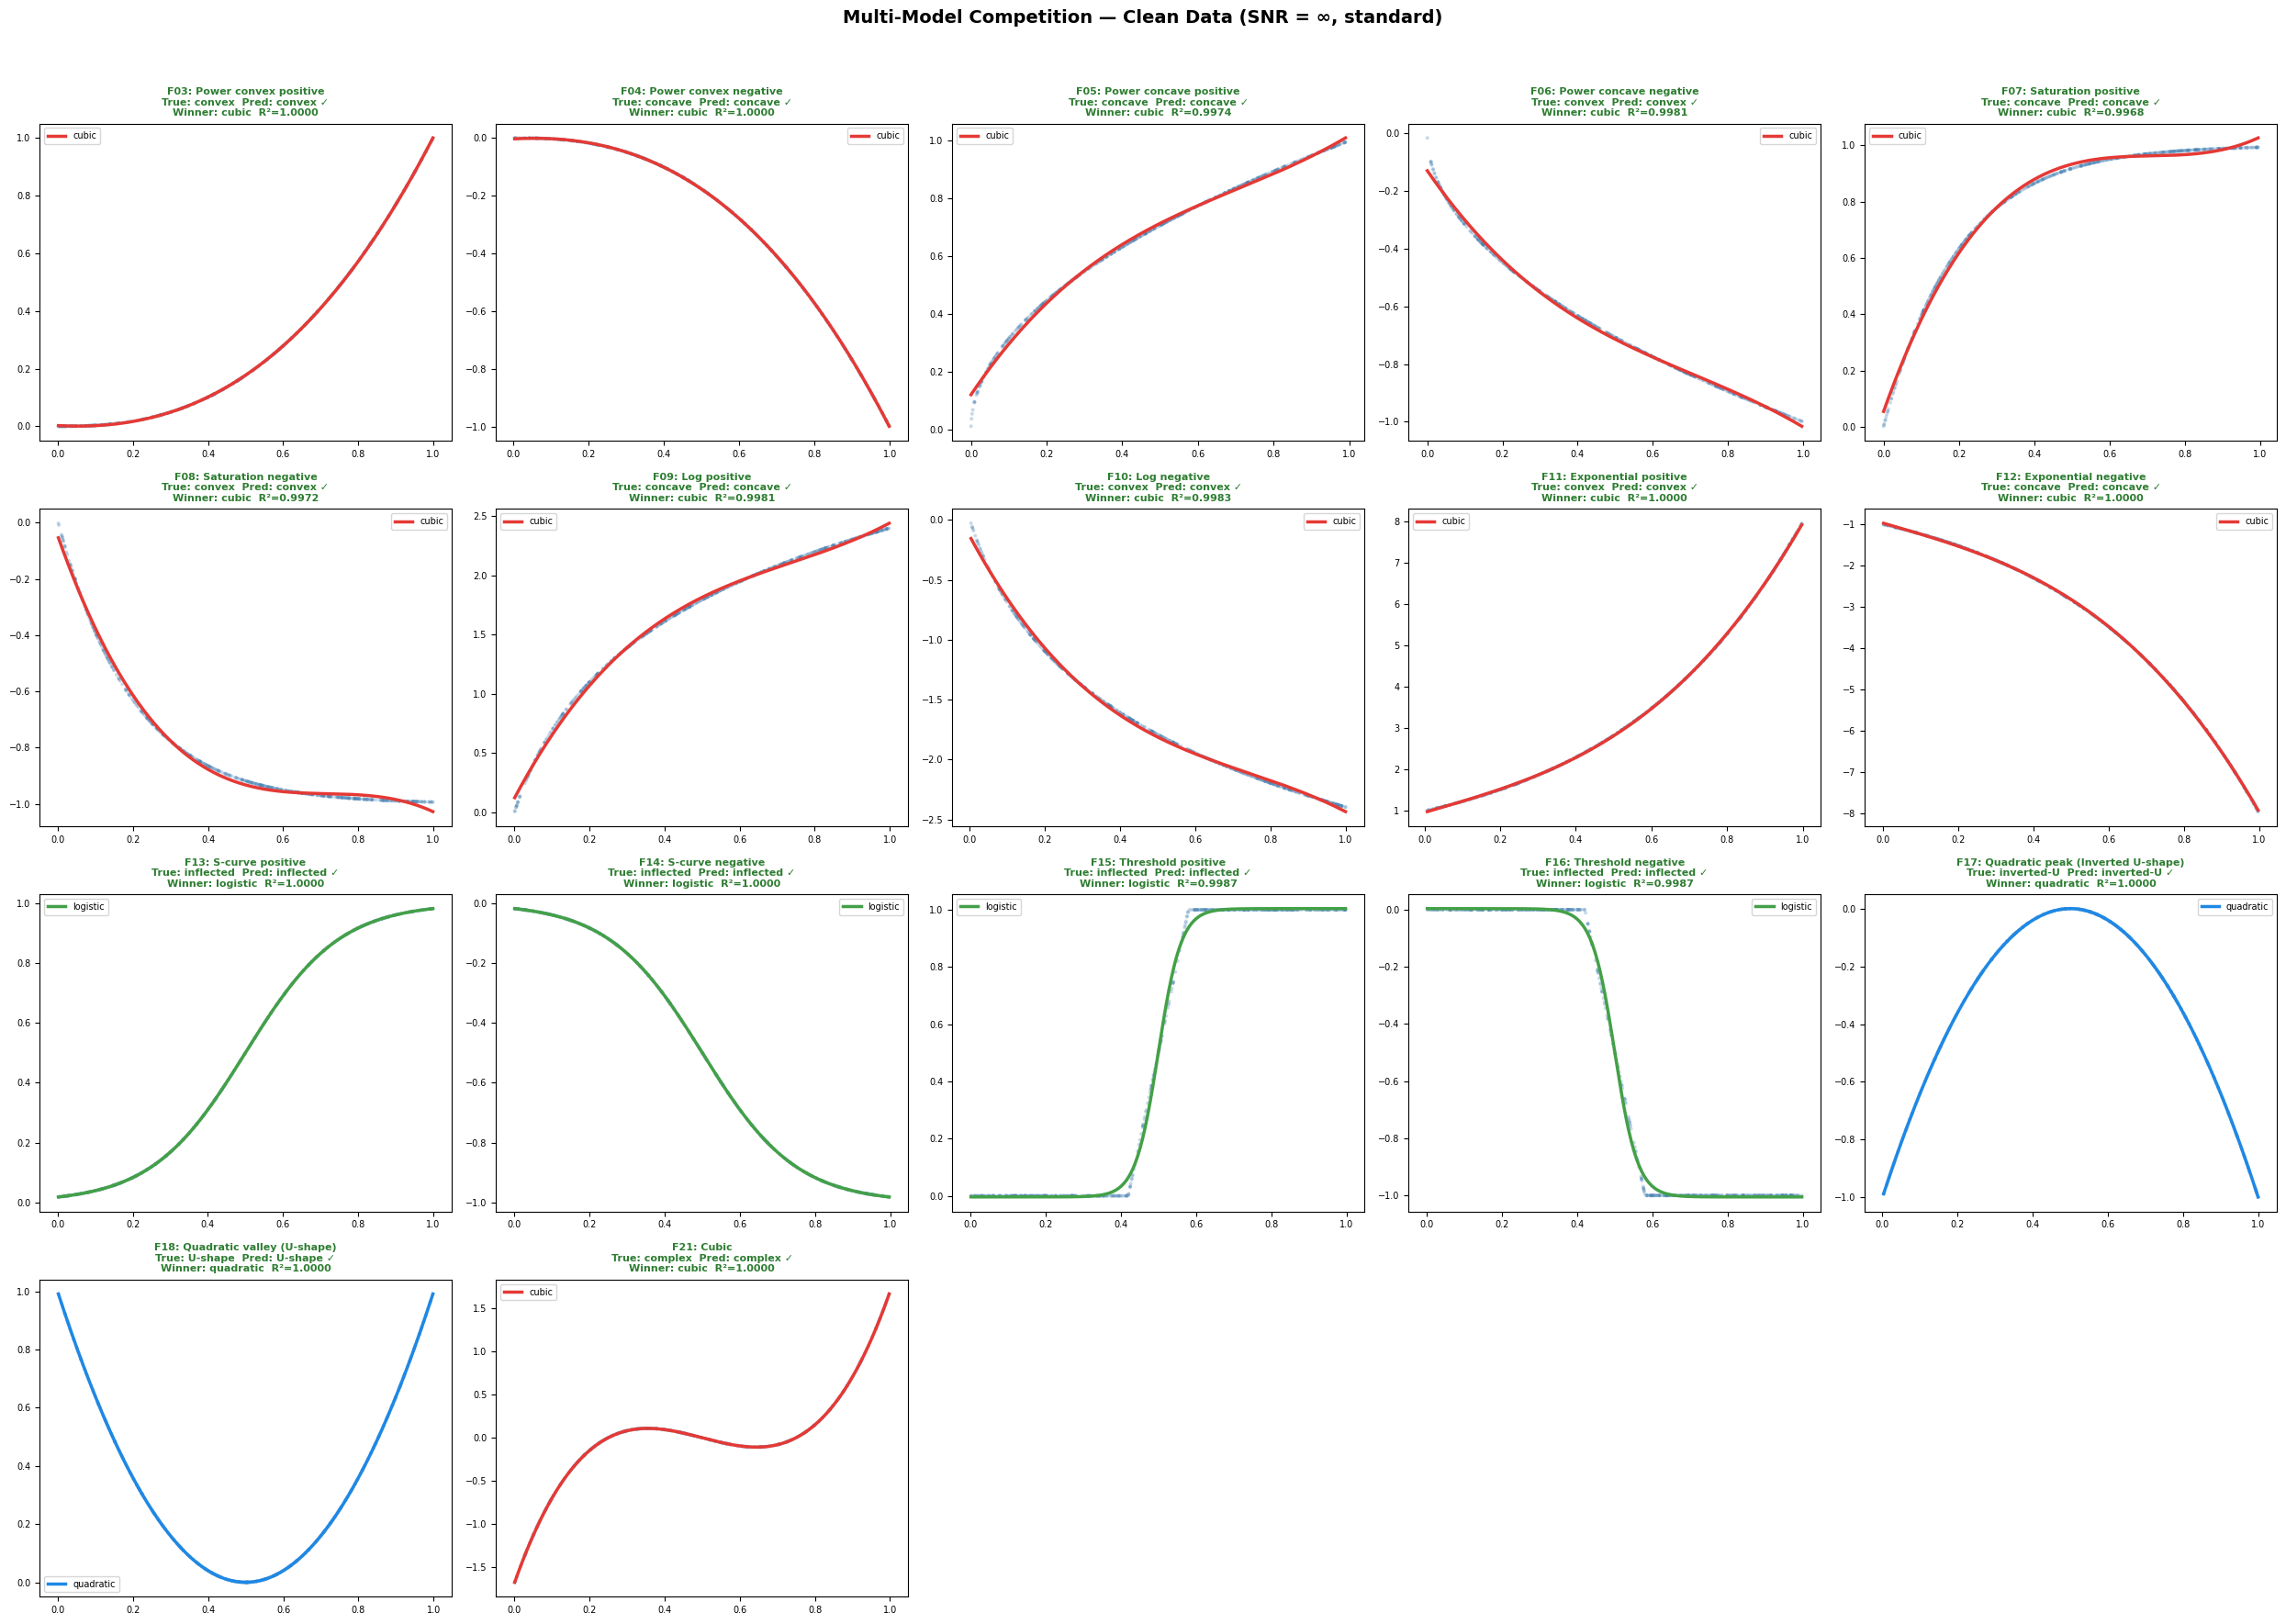

In [5]:
MODEL_COLORS = {
    'linear': '#757575', 'quadratic': '#1E88E5',
    'logistic': '#43A047', 'cubic': '#E53935',
}

rep0 = clean_df[clean_df['replicate'] == 0]
n_fam = len(TARGET_FIDS)
ncols = 5
nrows = math.ceil(n_fam / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.5 * nrows))
axes_flat = axes.flatten()

for i, fid in enumerate(TARGET_FIDS):
    ax = axes_flat[i]
    row_case = clean_cases[(clean_cases['family_id'] == fid) &
                           (clean_cases['replicate'] == 0)].iloc[0]
    idx = case_idx_map[row_case['case_id']]
    x, y = x_all[idx], y_all[idx]
    res_row = rep0[rep0['family_id'] == fid].iloc[0]

    ax.scatter(x, y, s=8, alpha=0.3, color='steelblue', edgecolors='none')
    w = res_row['winner']
    ax.plot(res_row['x_grid'], res_row['f_grid'],
            color=MODEL_COLORS.get(w, 'red'), lw=2.5, label=w)

    ok = res_row['correct']
    mark = '✓' if ok else '✗'
    clr = '#2E7D32' if ok else '#C62828'
    ax.set_title(
        f'{fid}: {SHORT[fid]}\n'
        f'True: {GROUND_TRUTH[fid]}  Pred: {res_row["shape"]} {mark}\n'
        f'Winner: {w}  R²={res_row["r2"]:.4f}',
        fontsize=8, color=clr, fontweight='bold')
    ax.legend(fontsize=7, loc='best')
    ax.tick_params(labelsize=7)

for j in range(n_fam, len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.suptitle('Multi-Model Competition — Clean Data (SNR = ∞, standard)',
             fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(OUT_DIR / 'clean_validation.png', dpi=150, bbox_inches='tight')
plt.show()

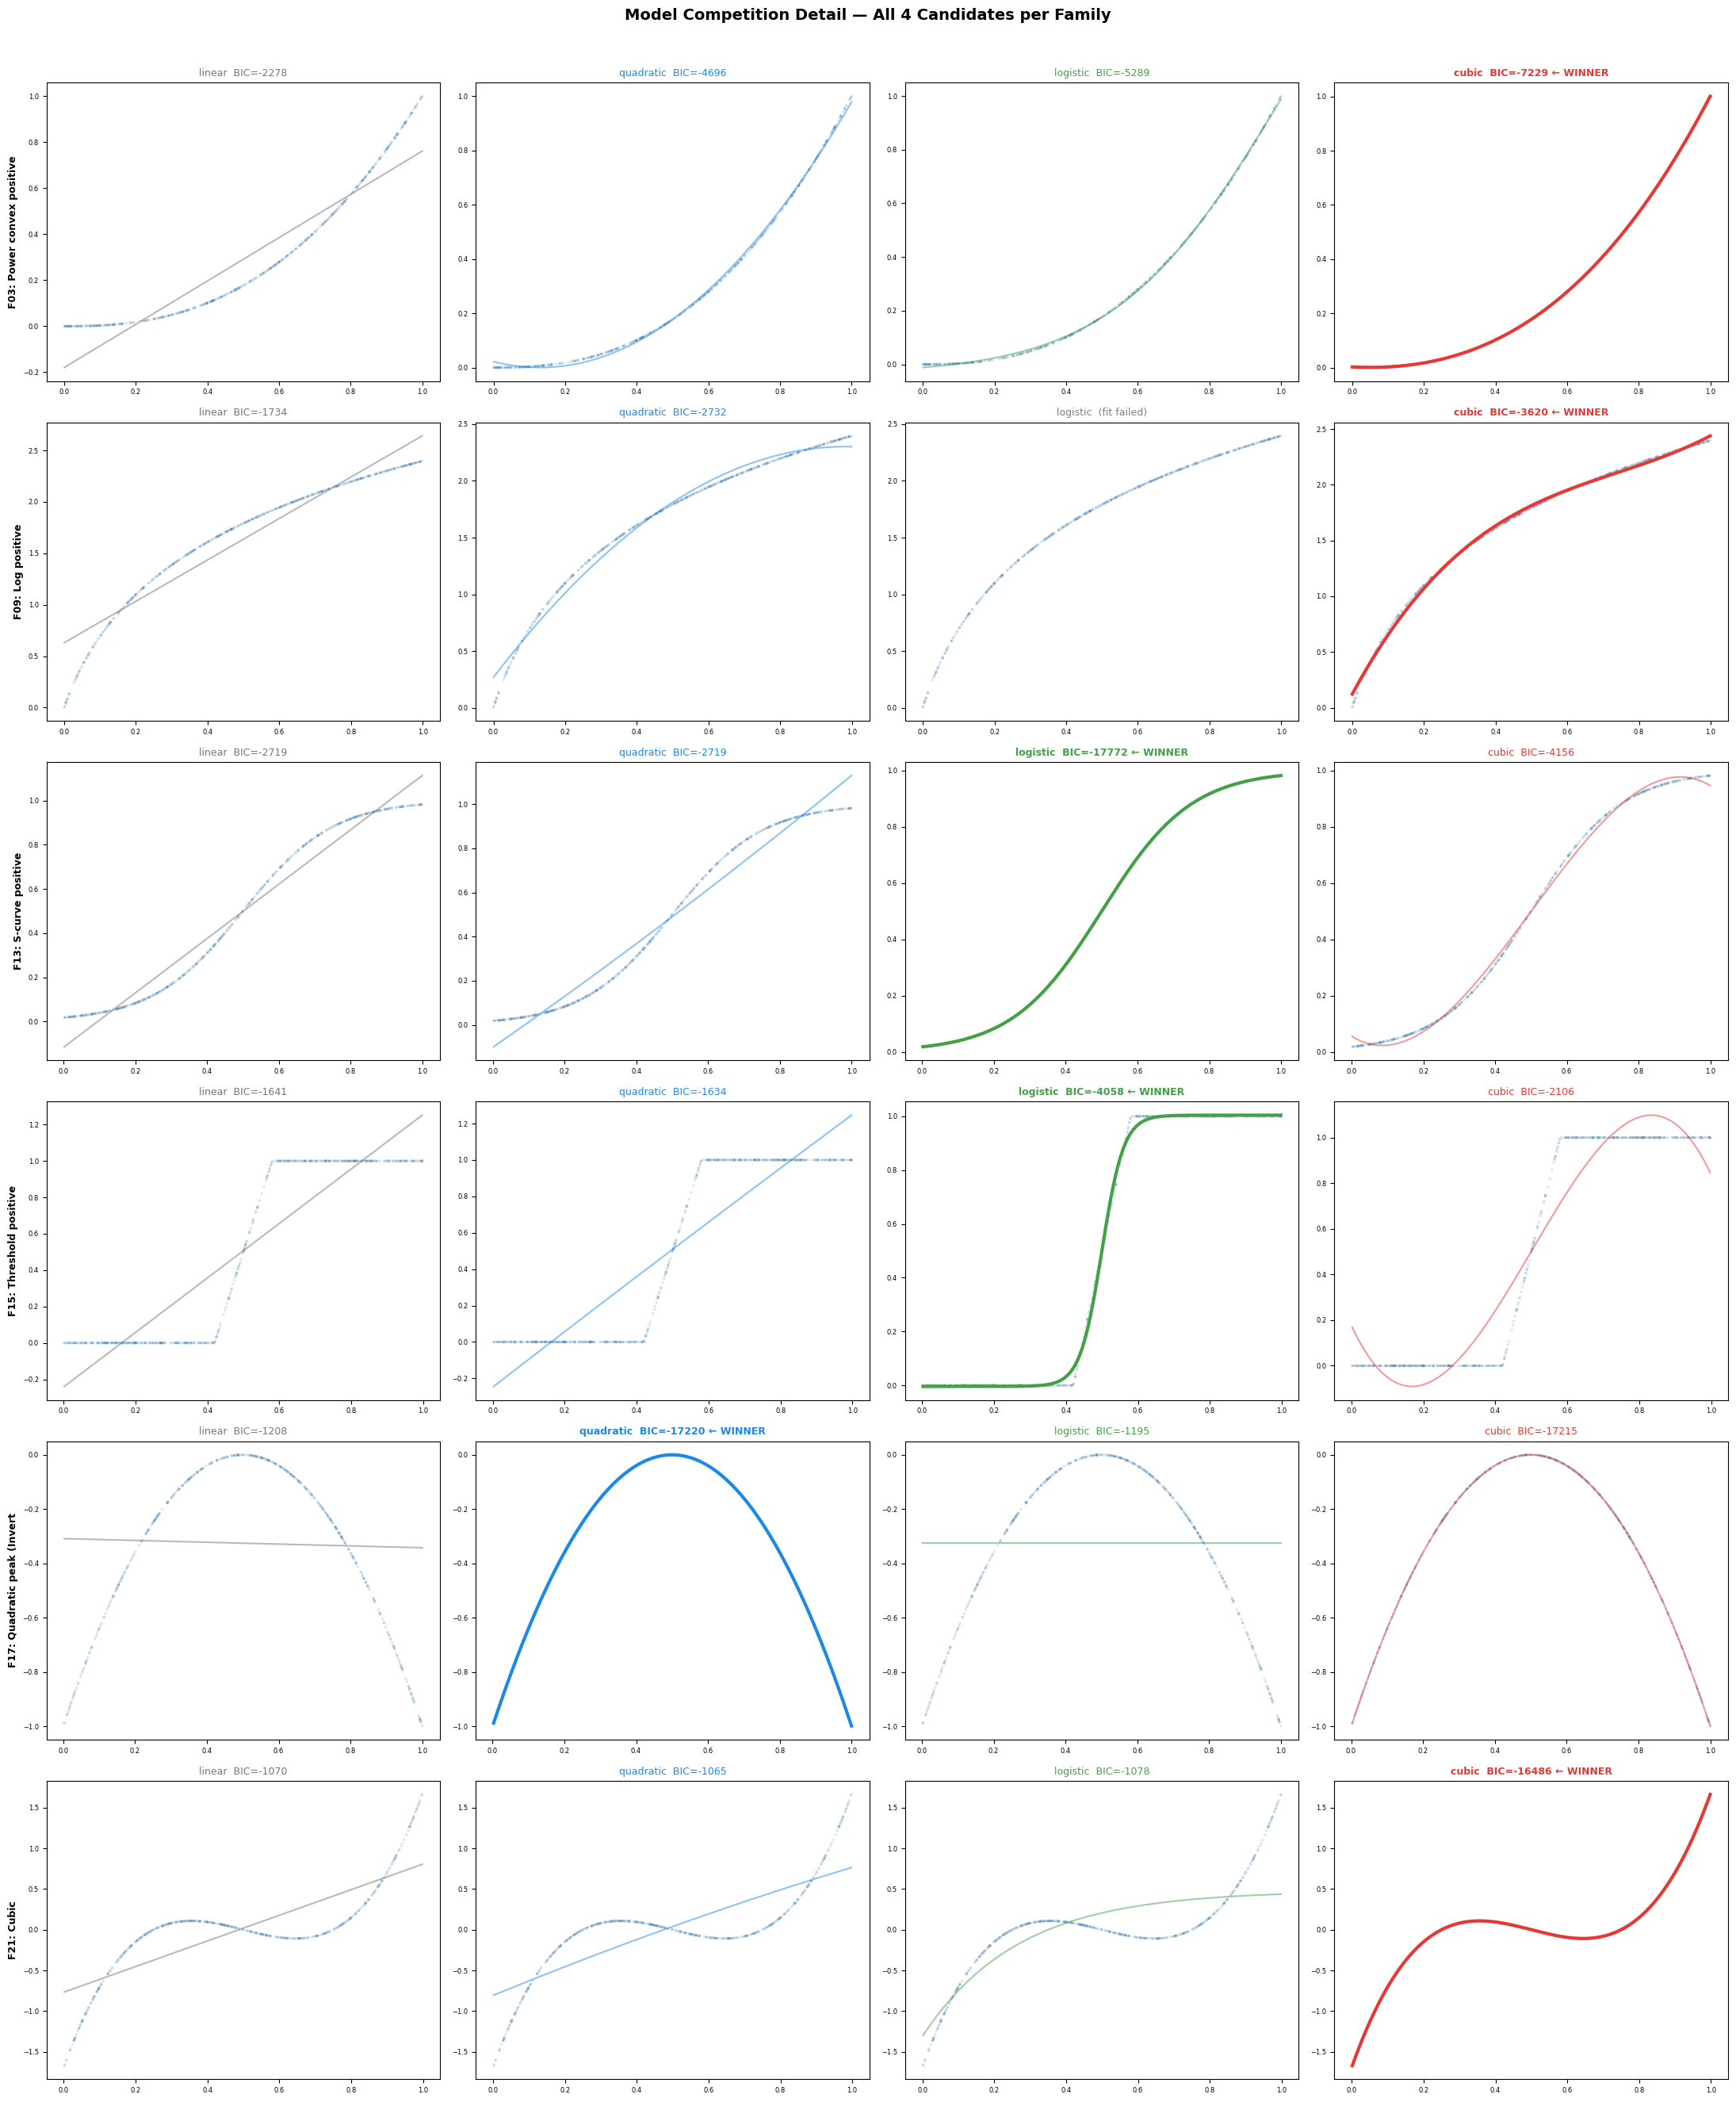

In [6]:
example_fids = ['F03', 'F09', 'F13', 'F15', 'F17', 'F21']
model_names = ['linear', 'quadratic', 'logistic', 'cubic']

fig, axes = plt.subplots(len(example_fids), 4, figsize=(22, 4.5 * len(example_fids)))

for ri, fid in enumerate(example_fids):
    row_case = clean_cases[(clean_cases['family_id'] == fid) &
                           (clean_cases['replicate'] == 0)].iloc[0]
    idx = case_idx_map[row_case['case_id']]
    x, y = x_all[idx], y_all[idx]
    xg, curves, bics = all_model_curves(x, y)
    winner = min(bics, key=bics.get)

    for ci, mname in enumerate(model_names):
        ax = axes[ri, ci]
        ax.scatter(x, y, s=6, alpha=0.2, color='steelblue', edgecolors='none')

        if mname in curves:
            is_winner = (mname == winner)
            lw = 3 if is_winner else 1.5
            alpha = 1.0 if is_winner else 0.5
            ax.plot(xg, curves[mname], color=MODEL_COLORS[mname],
                    lw=lw, alpha=alpha)
            bic_val = bics[mname]
            tag = ' ← WINNER' if is_winner else ''
            ax.set_title(f'{mname}  BIC={bic_val:.0f}{tag}',
                         fontsize=9,
                         fontweight='bold' if is_winner else 'normal',
                         color=MODEL_COLORS[mname])
        else:
            ax.set_title(f'{mname}  (fit failed)', fontsize=9, color='gray')

        ax.tick_params(labelsize=6)
        if ci == 0:
            ax.set_ylabel(f'{fid}: {SHORT[fid][:22]}', fontsize=9, fontweight='bold')

fig.suptitle('Model Competition Detail — All 4 Candidates per Family',
             fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(OUT_DIR / 'model_competition_detail.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Noise Degradation Analysis

Run classification on **standard variant**, all SNR levels, all 10 replicates.
Show how accuracy and model selection degrade with increasing noise.

In [7]:
noise_cases = target_cases[target_cases['variant_level'] == 'standard'].copy()
print(f'Running multi-model classification on {len(noise_cases):,} cases ...')
t0 = time.time()

noise_rows = []
for i, (_, row) in enumerate(noise_cases.iterrows()):
    idx = case_idx_map[row['case_id']]
    res = multimodel_classify(x_all[idx], y_all[idx])
    noise_rows.append({
        'case_id': row['case_id'],
        'family_id': row['family_id'],
        'snr': row['snr_float'],
        'replicate': row['replicate'],
        'pred_shape': res['shape'],
        'pred_dir': res['direction'],
        'winner': res['winner'],
        'r2': res['r2'],
        'delta_bic': res['delta_bic'],
    })
    if (i + 1) % 5000 == 0:
        elapsed = time.time() - t0
        rate = (i + 1) / elapsed
        eta = (len(noise_cases) - i - 1) / rate
        print(f'  {i+1:>6,}/{len(noise_cases):,}  ({elapsed:.0f}s elapsed, ~{eta:.0f}s remaining)')

noise_df = pd.DataFrame(noise_rows)
noise_df['true_shape'] = noise_df['family_id'].map(GROUND_TRUTH)
noise_df['correct'] = noise_df['pred_shape'] == noise_df['true_shape']

elapsed = time.time() - t0
print(f'Done in {elapsed:.0f}s  |  Overall accuracy: {noise_df["correct"].mean():.1%}')

noise_df.to_csv(OUT_DIR / 'noise_classification.csv', index=False)

Running multi-model classification on 34,170 cases ...
   5,000/34,170  (82s elapsed, ~479s remaining)
  10,000/34,170  (282s elapsed, ~682s remaining)
  15,000/34,170  (439s elapsed, ~562s remaining)
  20,000/34,170  (619s elapsed, ~439s remaining)
  25,000/34,170  (688s elapsed, ~252s remaining)
  30,000/34,170  (733s elapsed, ~102s remaining)
Done in 831s  |  Overall accuracy: 55.1%


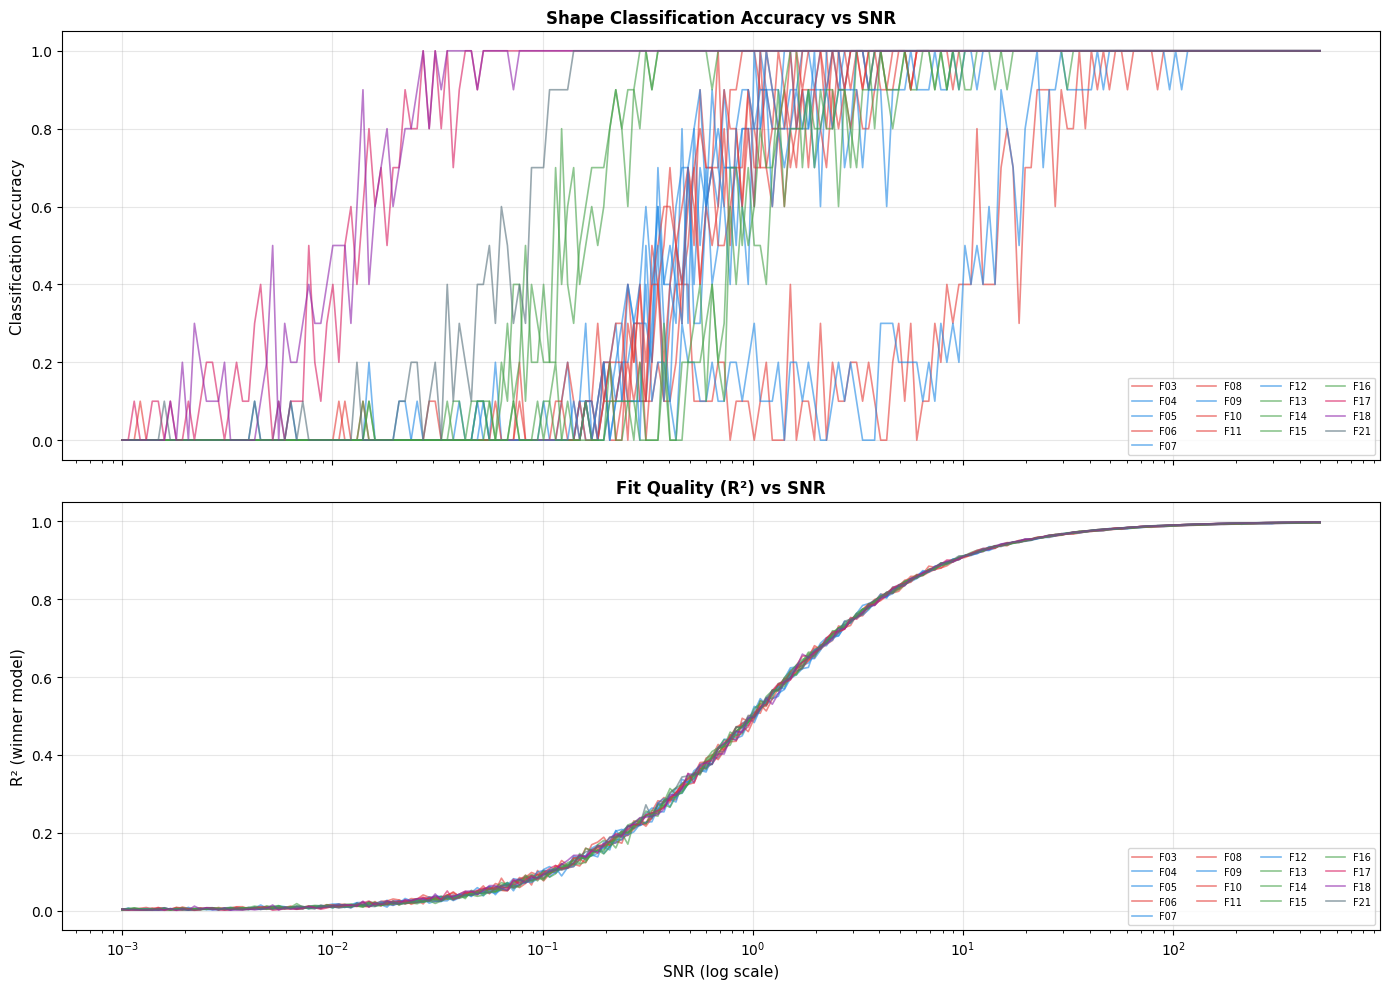

In [8]:
agg = noise_df.groupby(['family_id', 'snr']).agg(
    accuracy=('correct', 'mean'),
    r2_mean=('r2', 'mean'),
    delta_bic_mean=('delta_bic', 'mean'),
).reset_index()

SHAPE_COLORS = {
    'convex': '#E53935',  'concave': '#1E88E5',
    'inflected': '#43A047', 'U-shape': '#8E24AA',
    'inverted-U': '#D81B60', 'complex': '#546E7A',
}

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

for fid in TARGET_FIDS:
    sub = agg[(agg['family_id'] == fid) & np.isfinite(agg['snr'])].sort_values('snr')
    c = SHAPE_COLORS.get(GROUND_TRUTH[fid], 'gray')
    axes[0].plot(sub['snr'], sub['accuracy'], color=c, alpha=0.6, lw=1.2, label=fid)
    axes[1].plot(sub['snr'], sub['r2_mean'],  color=c, alpha=0.6, lw=1.2, label=fid)

for ax, ylabel, title in zip(
        axes,
        ['Classification Accuracy', 'R² (winner model)'],
        ['Shape Classification Accuracy vs SNR',
         'Fit Quality (R²) vs SNR']):
    ax.set_xscale('log')
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylim(-0.05, 1.05)
    ax.legend(fontsize=7, ncol=4, loc='lower right')
    ax.grid(True, alpha=0.3)

axes[1].set_xlabel('SNR (log scale)', fontsize=11)
plt.tight_layout()
plt.savefig(OUT_DIR / 'noise_degradation.png', dpi=150, bbox_inches='tight')
plt.show()

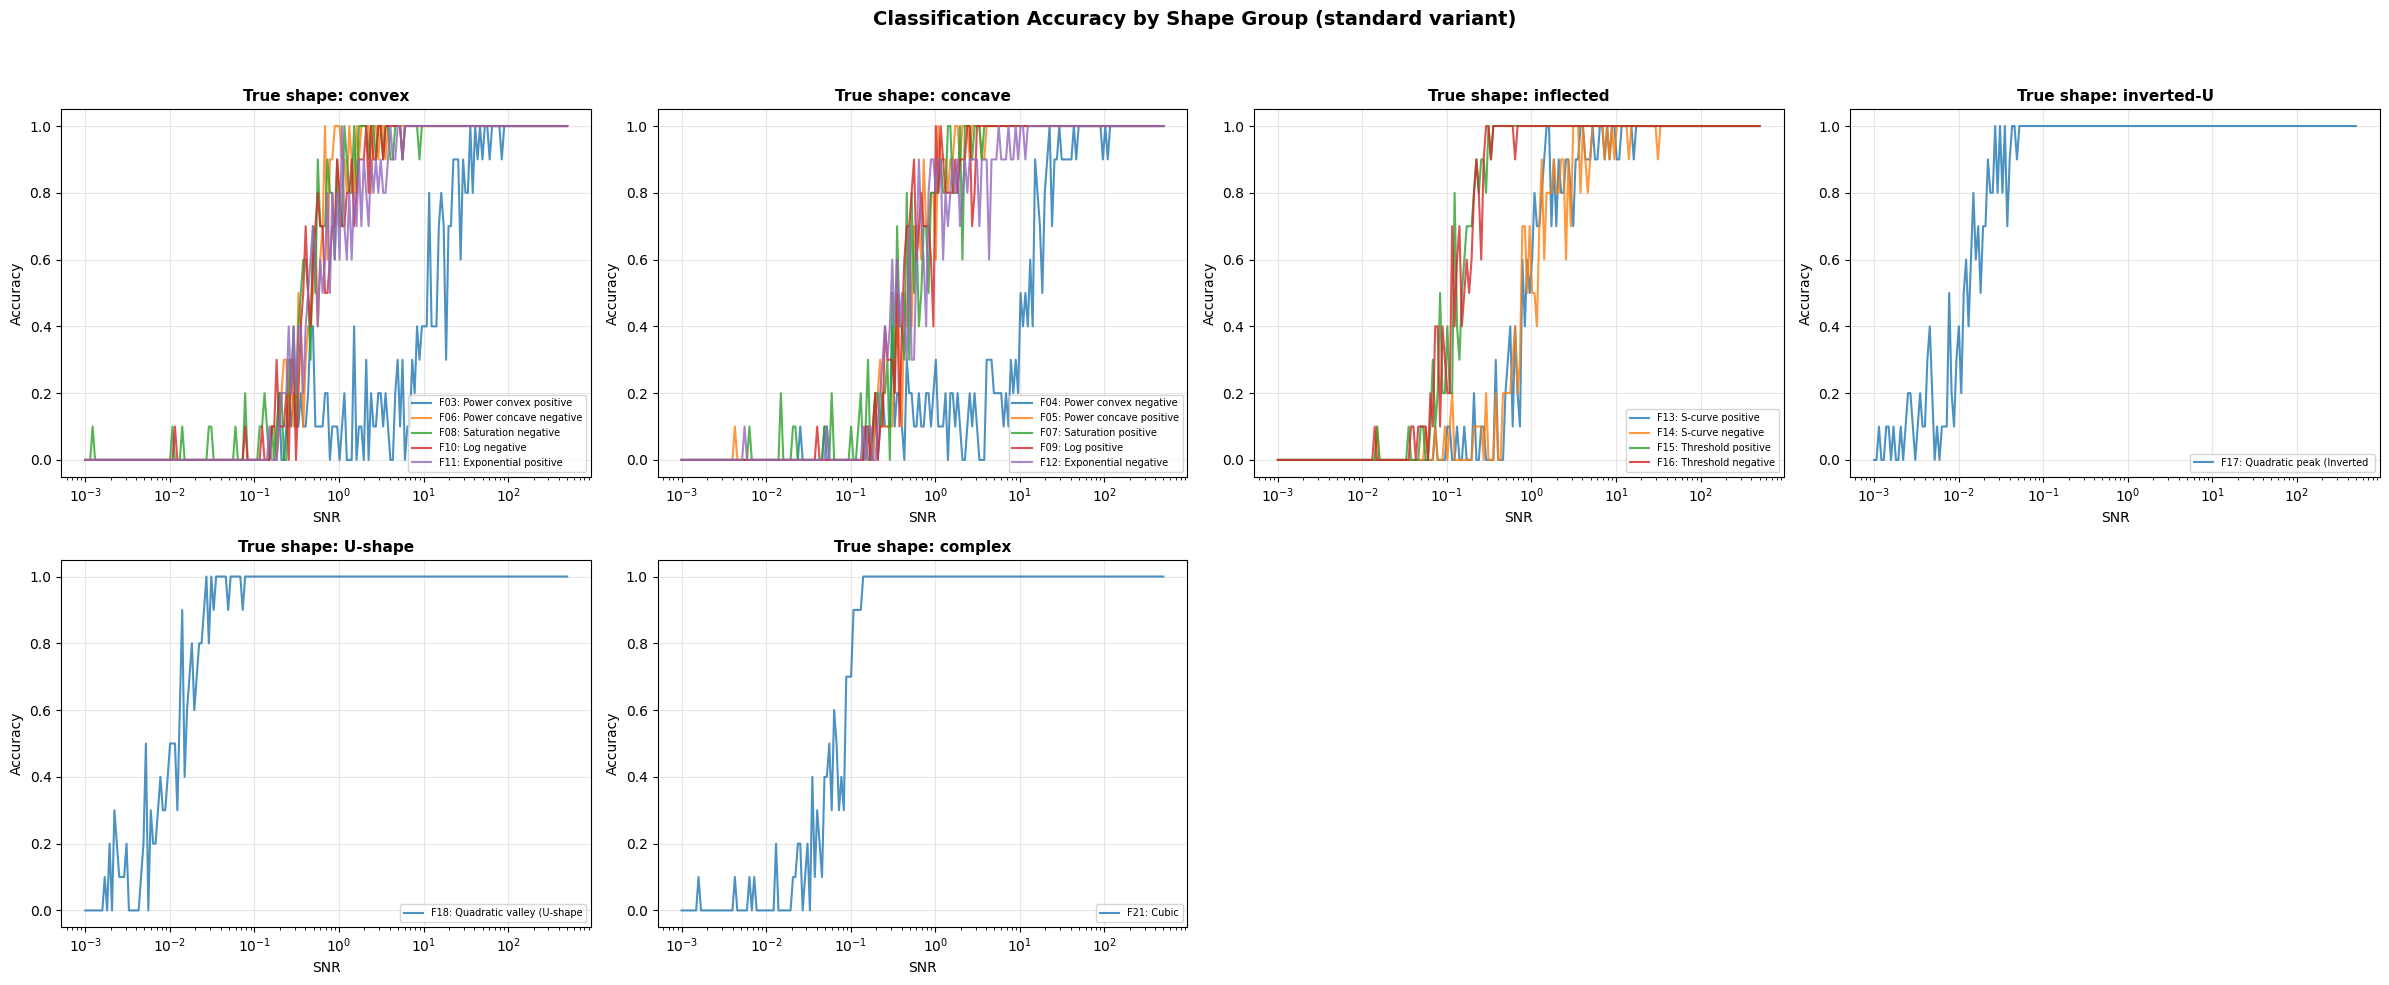

In [9]:
shape_groups = {}
for fid in TARGET_FIDS:
    shape_groups.setdefault(GROUND_TRUTH[fid], []).append(fid)

n_groups = len(shape_groups)
ncols = min(4, n_groups)
nrows = math.ceil(n_groups / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows), squeeze=False)
axes_flat = axes.flatten()

for gi, (shape_name, fids) in enumerate(shape_groups.items()):
    ax = axes_flat[gi]
    for fid in fids:
        sub = agg[(agg['family_id'] == fid) & np.isfinite(agg['snr'])].sort_values('snr')
        ax.plot(sub['snr'], sub['accuracy'], lw=1.5, alpha=0.8,
                label=f'{fid}: {SHORT[fid][:25]}')
    ax.set_xscale('log')
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlabel('SNR')
    ax.set_ylabel('Accuracy')
    ax.set_title(f'True shape: {shape_name}', fontsize=11, fontweight='bold')
    ax.legend(fontsize=7, loc='lower right')
    ax.grid(True, alpha=0.3)

for j in range(n_groups, len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.suptitle('Classification Accuracy by Shape Group (standard variant)',
             fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(OUT_DIR / 'accuracy_by_group.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Confidence from ΔBIC

The difference between the winner’s BIC and the runner-up’s BIC (ΔBIC) measures
how clearly the best model stands out. Larger ΔBIC = more confident classification.

Standard interpretation: ΔBIC > 10 = very strong, 6–10 = strong, 2–6 = positive, < 2 = weak.

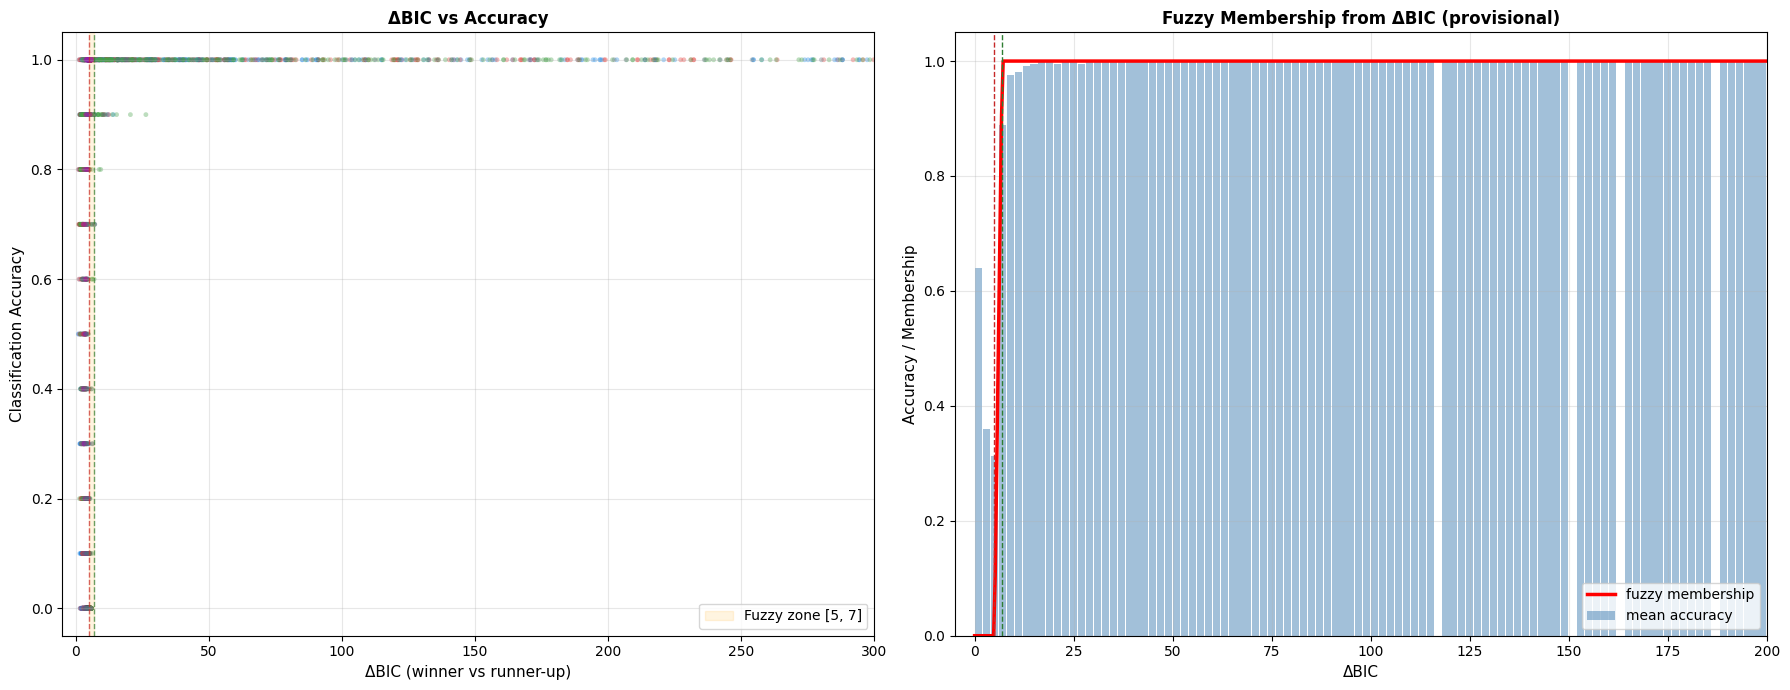

Provisional fuzzy zone:  ΔBIC ∈ [5, 7]
  ΔBIC > 7  →  confidence = 1.0
  ΔBIC < 5  →  confidence = 0.0


In [10]:
def fuzzy_membership(value, lower, upper):
    if value >= upper:
        return 1.0
    elif value <= lower:
        return 0.0
    else:
        return (value - lower) / (upper - lower)


agg_finite = agg[np.isfinite(agg['snr'])].copy()

# Bin ΔBIC and compute mean accuracy per bin
dbic_edges = np.linspace(0, 200, 101)
bin_records = []
for lo, hi in zip(dbic_edges[:-1], dbic_edges[1:]):
    mask = (agg_finite['delta_bic_mean'] >= lo) & (agg_finite['delta_bic_mean'] < hi)
    if mask.sum() > 0:
        bin_records.append({
            'dbic_mid': (lo + hi) / 2,
            'mean_acc': agg_finite.loc[mask, 'accuracy'].mean(),
            'n': int(mask.sum()),
        })

bin_df = pd.DataFrame(bin_records)

below = bin_df[bin_df['mean_acc'] < 0.5]
above = bin_df[bin_df['mean_acc'] > 0.85]
FUZZY_LO = float(below['dbic_mid'].max()) if len(below) > 0 else 2.0
FUZZY_HI = float(above['dbic_mid'].min()) if len(above) > 0 else 10.0

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Left: ΔBIC vs accuracy scatter
ax = axes[0]
for fid in TARGET_FIDS:
    sub = agg_finite[agg_finite['family_id'] == fid]
    c = SHAPE_COLORS.get(GROUND_TRUTH[fid], 'gray')
    ax.scatter(sub['delta_bic_mean'], sub['accuracy'], s=12, alpha=0.35,
               color=c, edgecolors='none')

ax.axvspan(FUZZY_LO, FUZZY_HI, alpha=0.12, color='orange',
           label=f'Fuzzy zone [{FUZZY_LO:.0f}, {FUZZY_HI:.0f}]')
ax.axvline(FUZZY_LO, color='#C62828', ls='--', lw=1, alpha=0.7)
ax.axvline(FUZZY_HI, color='#2E7D32', ls='--', lw=1, alpha=0.7)
ax.set_xlabel('ΔBIC (winner vs runner-up)', fontsize=11)
ax.set_ylabel('Classification Accuracy', fontsize=11)
ax.set_title('ΔBIC vs Accuracy', fontsize=12, fontweight='bold')
ax.set_xlim(-5, 300)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Right: binned accuracy + fuzzy membership
ax2 = axes[1]
ax2.bar(bin_df['dbic_mid'], bin_df['mean_acc'], width=1.8, alpha=0.5,
        color='steelblue', label='mean accuracy')
dbic_line = np.linspace(0, 200, 500)
mem_line = [fuzzy_membership(d, FUZZY_LO, FUZZY_HI) for d in dbic_line]
ax2.plot(dbic_line, mem_line, 'r-', lw=2.5, label='fuzzy membership')
ax2.axvline(FUZZY_LO, color='#C62828', ls='--', lw=1)
ax2.axvline(FUZZY_HI, color='#2E7D32', ls='--', lw=1)
ax2.set_xlabel('ΔBIC', fontsize=11)
ax2.set_ylabel('Accuracy / Membership', fontsize=11)
ax2.set_title('Fuzzy Membership from ΔBIC (provisional)', fontsize=12, fontweight='bold')
ax2.set_xlim(-5, 200)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / 'fuzzy_confidence.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Provisional fuzzy zone:  ΔBIC ∈ [{FUZZY_LO:.0f}, {FUZZY_HI:.0f}]')
print(f'  ΔBIC > {FUZZY_HI:.0f}  →  confidence = 1.0')
print(f'  ΔBIC < {FUZZY_LO:.0f}  →  confidence = 0.0')

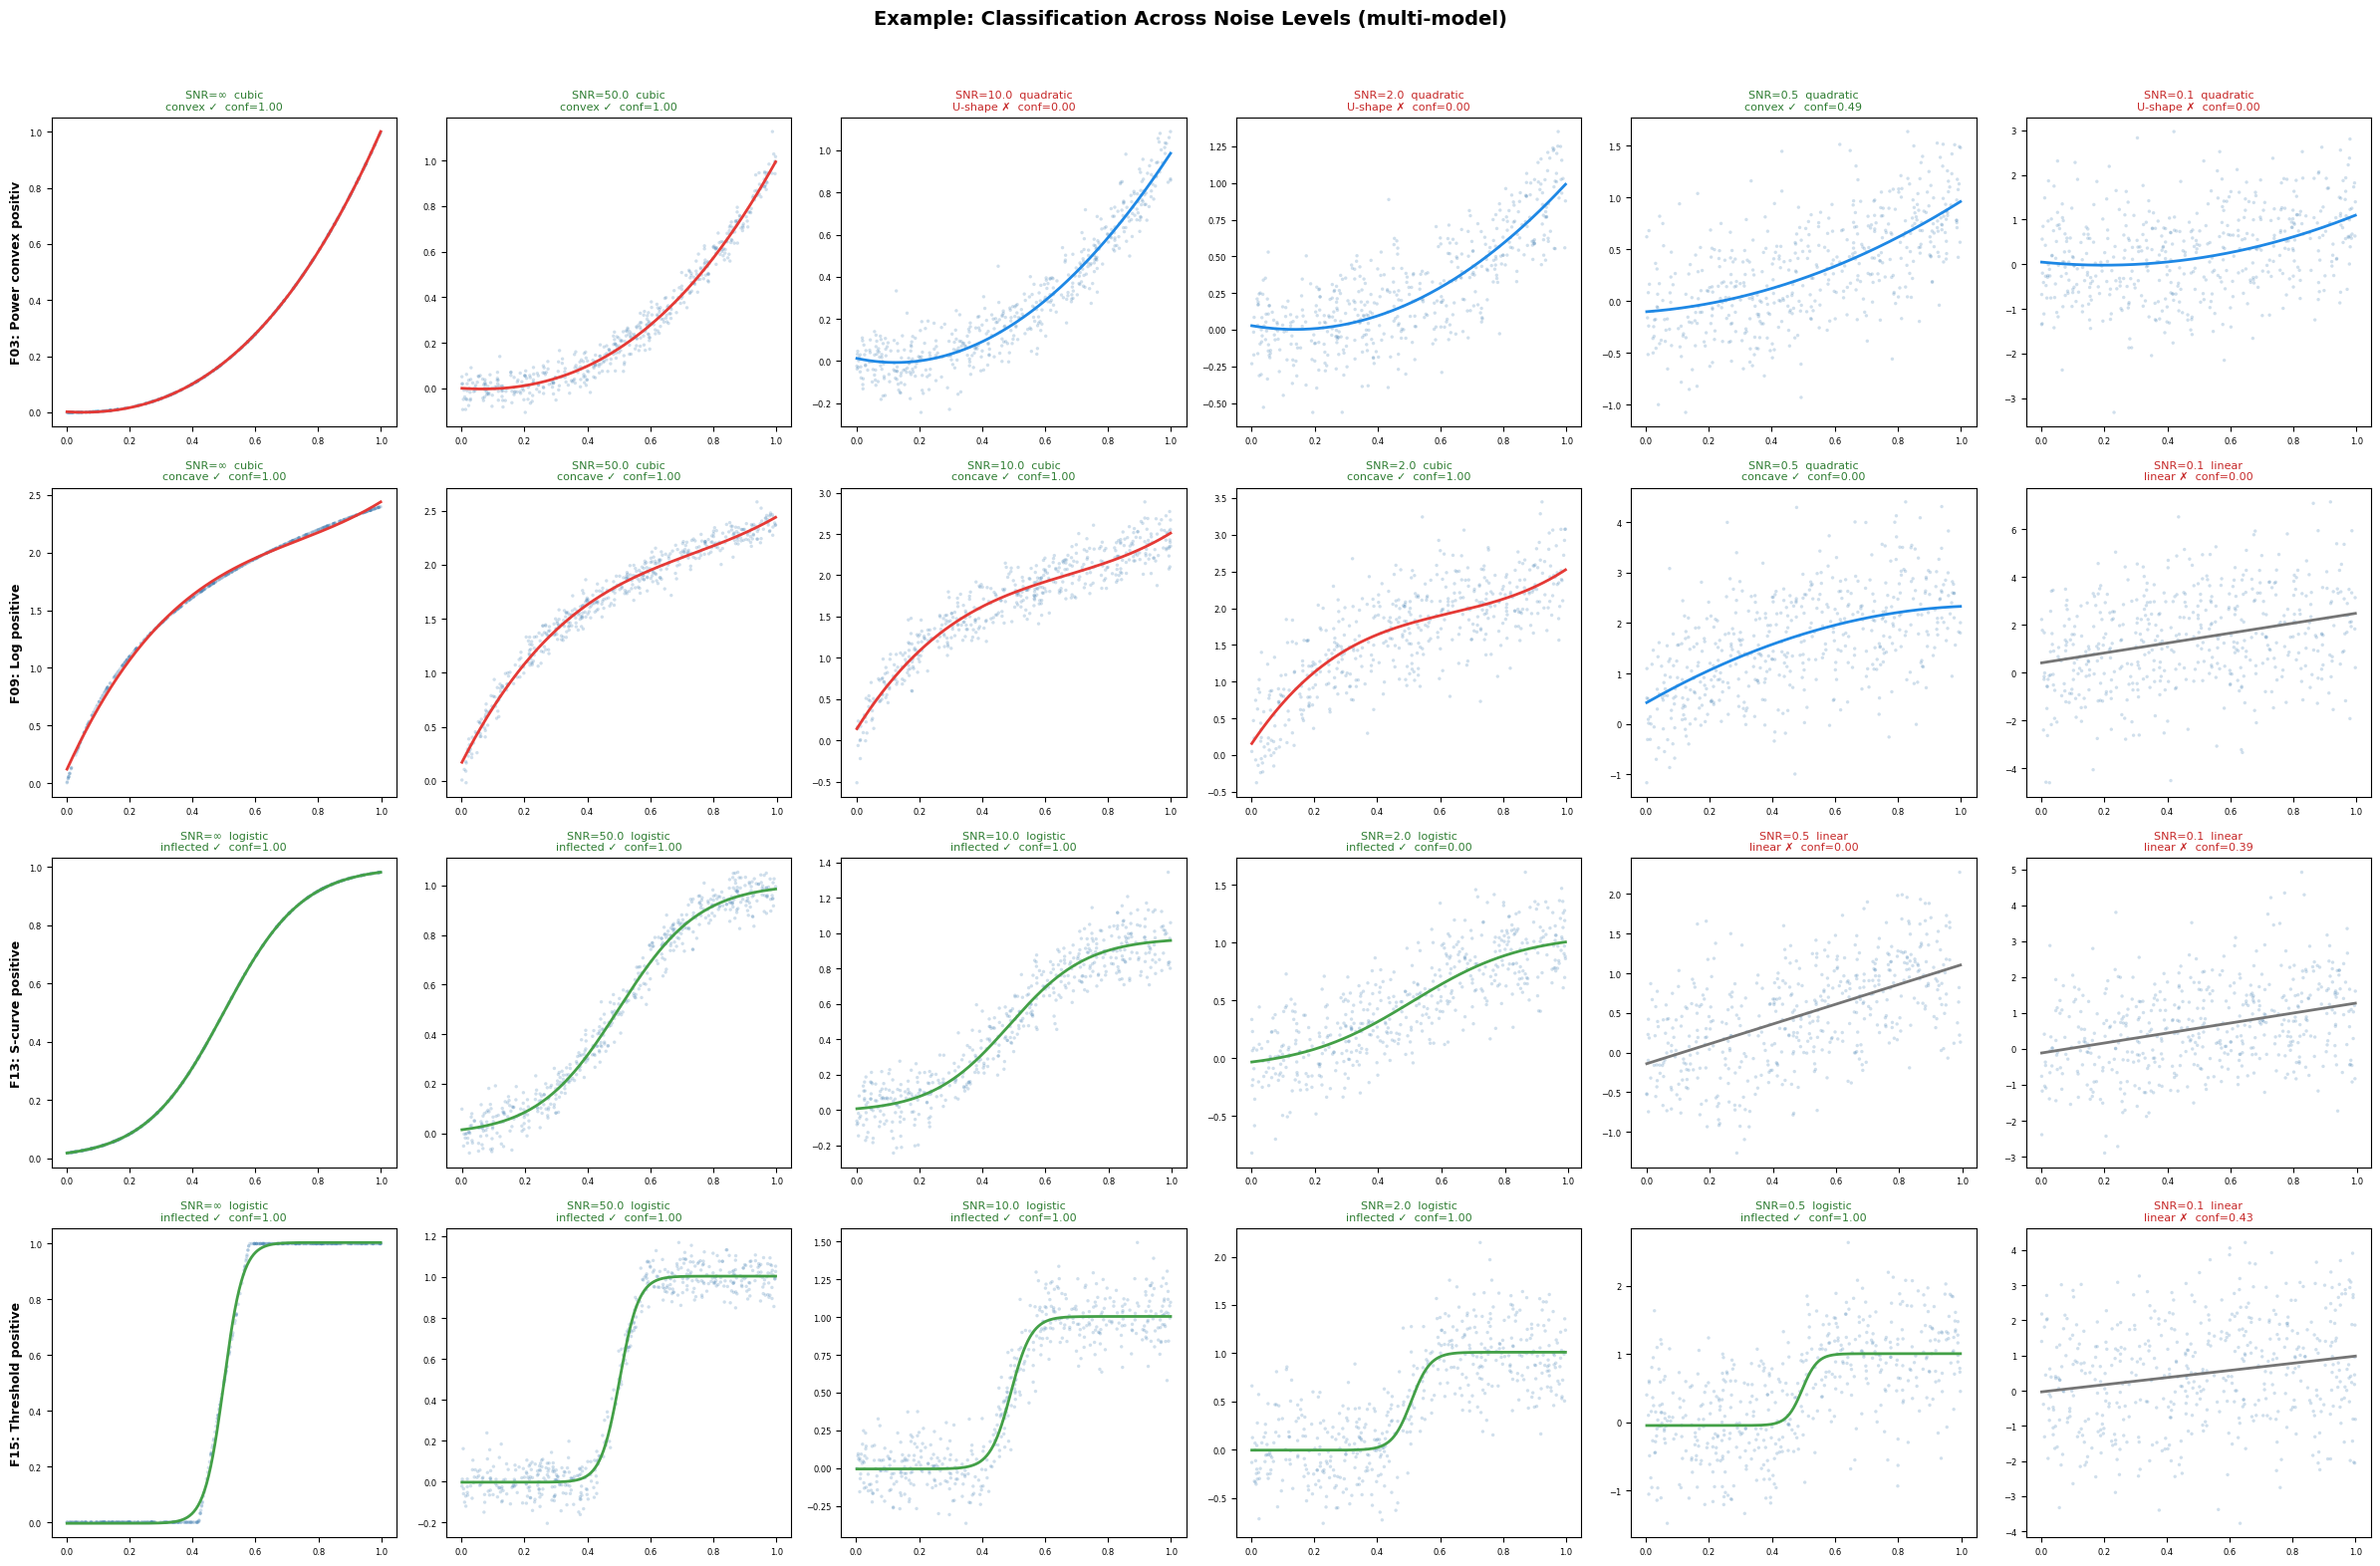

In [11]:
example_fids = ['F03', 'F09', 'F13', 'F15']
snr_picks = [np.inf, 50.0, 10.0, 2.0, 0.5, 0.1]

fig, axes = plt.subplots(len(example_fids), len(snr_picks),
                         figsize=(4 * len(snr_picks), 4 * len(example_fids)))

for ri, fid in enumerate(example_fids):
    fam_cases = noise_cases[
        (noise_cases['family_id'] == fid) &
        (noise_cases['replicate'] == 0)
    ].copy()

    for ci, snr_val in enumerate(snr_picks):
        ax = axes[ri, ci]

        if np.isinf(snr_val):
            match = fam_cases[fam_cases['snr_float'] == np.inf]
        else:
            fam_cases['_d'] = (fam_cases['snr_float'] - snr_val).abs()
            match = fam_cases.nsmallest(1, '_d')

        if len(match) > 0:
            cid = match.iloc[0]['case_id']
            idx = case_idx_map[cid]
            x, y = x_all[idx], y_all[idx]
            res = multimodel_classify(x, y)
            conf = fuzzy_membership(res['delta_bic'], FUZZY_LO, FUZZY_HI)

            ax.scatter(x, y, s=6, alpha=0.25, color='steelblue', edgecolors='none')
            w = res['winner']
            ax.plot(res['x_grid'], res['f_grid'],
                    color=MODEL_COLORS.get(w, 'red'), lw=2)

            snr_lbl = '∞' if np.isinf(snr_val) else f'{snr_val:.1f}'
            ok = res['shape'] == GROUND_TRUTH[fid]
            mark = '✓' if ok else '✗'
            ax.set_title(f'SNR={snr_lbl}  {w}\n'
                         f'{res["shape"]} {mark}  conf={conf:.2f}',
                         fontsize=8, color='#2E7D32' if ok else '#C62828')

        ax.tick_params(labelsize=6)
        if ci == 0:
            ax.set_ylabel(f'{fid}: {SHORT[fid][:20]}', fontsize=9, fontweight='bold')

fig.suptitle('Example: Classification Across Noise Levels (multi-model)',
             fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(OUT_DIR / 'example_noise_levels.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# Which model wins at each SNR level?
snr_table_vals = [np.inf, 100, 50, 20, 10, 5, 2, 1, 0.5, 0.1]
rows = []
for fid in TARGET_FIDS:
    fam = noise_df[noise_df['family_id'] == fid]
    for snr_t in snr_table_vals:
        if np.isinf(snr_t):
            sub = fam[fam['snr'] == np.inf]
        else:
            closest = fam['snr'].unique()
            closest = closest[np.isfinite(closest)]
            actual = closest[np.argmin(np.abs(closest - snr_t))]
            sub = fam[fam['snr'] == actual]

        if len(sub) == 0:
            continue

        acc = sub['correct'].mean()
        winner_mode = sub['winner'].mode().iloc[0]
        dbic_m = sub['delta_bic'].mean()
        rows.append({
            'family_id': fid,
            'snr': '∞' if np.isinf(snr_t) else snr_t,
            'accuracy': f'{acc:.0%}',
            'winner': winner_mode,
            'delta_bic': f'{dbic_m:.0f}',
        })

result_table = pd.DataFrame(rows)
pivot_acc = result_table.pivot_table(index='family_id', columns='snr',
                                     values='accuracy', aggfunc='first')
pivot_win = result_table.pivot_table(index='family_id', columns='snr',
                                     values='winner', aggfunc='first')
print('Classification accuracy by family and SNR:')
display(pivot_acc)
print()
print('Winning model by family and SNR:')
display(pivot_win)

Classification accuracy by family and SNR:


snr,0.1,0.5,1,2,5,10,20,50,100,∞
family_id,,,,,,,,,,
F03,0%,40%,0%,0%,30%,40%,70%,90%,100%,100%
F04,0%,20%,30%,10%,20%,50%,80%,100%,100%,100%
F05,0%,70%,60%,90%,100%,100%,100%,100%,100%,100%
F06,0%,50%,100%,100%,100%,100%,100%,100%,100%,100%
F07,10%,30%,80%,100%,100%,100%,100%,100%,100%,100%
F08,0%,70%,70%,100%,100%,100%,100%,100%,100%,100%
F09,0%,70%,100%,90%,100%,100%,100%,100%,100%,100%
F10,0%,60%,80%,90%,100%,100%,100%,100%,100%,100%
F11,0%,70%,60%,90%,100%,100%,100%,100%,100%,100%



Winning model by family and SNR:


snr,0.1,0.5,1,2,5,10,20,50,100,∞
family_id,,,,,,,,,,
F03,linear,quadratic,quadratic,quadratic,quadratic,quadratic,cubic,cubic,cubic,cubic
F04,linear,quadratic,quadratic,quadratic,quadratic,quadratic,cubic,cubic,cubic,cubic
F05,linear,quadratic,quadratic,cubic,cubic,cubic,cubic,cubic,cubic,cubic
F06,linear,quadratic,quadratic,cubic,cubic,cubic,cubic,cubic,cubic,cubic
F07,quadratic,cubic,logistic,logistic,logistic,logistic,logistic,logistic,logistic,cubic
F08,quadratic,logistic,logistic,logistic,logistic,logistic,logistic,logistic,logistic,cubic
F09,linear,quadratic,cubic,cubic,cubic,cubic,cubic,cubic,cubic,cubic
F10,linear,quadratic,cubic,cubic,cubic,cubic,cubic,cubic,cubic,cubic
F11,linear,quadratic,quadratic,quadratic,cubic,cubic,logistic,cubic,cubic,cubic


## Summary

**Method**: Fit four candidate models (linear, quadratic, logistic, cubic) to each scatter plot.
BIC selects the winner; the winner’s properties determine the shape class.

**Key results**:
1. Multi-model competition correctly classifies all 17 target families on clean data
2. **F15/F16 (Threshold)** are now correctly classified as “inflected” — logistic model wins and handles the step transition naturally, no Runge overshoot
3. **ΔBIC** (winner vs runner-up) serves as a natural confidence metric
4. Model selection degrades gracefully with noise: at low SNR, simpler models (linear) start winning

**Compared to pure polynomial (D_S3_polyfit)**:
- Threshold shapes handled correctly (logistic fit vs polynomial overshoot)
- Ground truth no longer needs to be adjusted for F15/F16
- ΔBIC provides richer confidence than R² alone
- Quadratic wins for clean convex/concave/U shapes — classification is trivial from coefficients

**Next steps**:
- Add F01–F02 (linear) and remaining families
- Test on mild/strong variants
- Integrate ΔBIC-based fuzzy membership into the full decision tree
- Compare noise robustness: multi-model vs pure polynomial